<div style="background: linear-gradient(135deg, #4C1D95 0%, #F5F3FF 100%); padding: 24px; border-radius: 12px; color: white; box-shadow: 0 4px 12px rgba(0, 0, 0, 0.1);">
    <h1 style="margin: 0 0 8px 0; color: #ffffff; font-size: 26px; font-weight: 800; border-bottom: none; padding: 0;">Classroom Analysis</h1>
    <div style="background: rgba(255, 255, 255, 0.2); padding: 8px 14px; border-radius: 6px; font-size: 13px; display: inline-block;">
        <strong>Author:</strong> Kathryn Penrod &nbsp;•&nbsp; 
        <strong>Goal:</strong> Clean the data
    </div>
</div>

In [1]:
import numpy as np 
import pandas as pd 
import scipy as sp 
from scipy import stats 
import matplotlib 
import sqlite3 
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates
import seaborn as sns 
import sklearn 
from sklearn.preprocessing import StandardScaler 
from sklearn.decomposition import PCA 
import warnings 
import re

In [2]:
df = pd.read_csv('2022 - Sheet1.csv')
df2 = pd.read_csv('Data Tracker_Research.xlsx - Data Tracker_Whole Class.csv', header=[0, 1])
###df3 = pd.read_csv('REDACTED', header=[0, 1])###

clean_df = df.copy()
clean_df2 = df2.copy()
clean_df3 = df3.copy()

In [3]:
#column names 1
for col in df.columns:
    print(col)

Building #
Grade
Subject
Teacher Years of Experience
Test Score Year 1
Test Score Year 2


In [4]:
#column names 2
for col in clean_df2.columns:
    print(col)

('STUDENT', 'Unnamed: 0_level_1')
('Pre-Test', 'Unnamed: 1_level_1')
('RN.2.1', 'Exit Ticket')
('Unnamed: 3_level_0', 'Exit Ticket')
('Unnamed: 4_level_0', 'Mastery')
('RN.2.2', 'CFU')
('Unnamed: 6_level_0', 'Exit')
('Unnamed: 7_level_0', 'Mastery')
('RN.3.3', 'CFU - AGGMO')
('Unnamed: 9_level_0', 'Mastery')
('W.3.3', 'Exit - HW')
('Unnamed: 11_level_0', 'Mastery')
('W.6.2', 'Exit Commas')
('Unnamed: 13_level_0', 'Exit Clauses')
('Unnamed: 14_level_0', 'Exit conj')
('Unnamed: 15_level_0', 'Mastery Combo')
('RL.2.1', 'practice ')
('Unnamed: 17_level_0', 'practice')
('RL.2.3', 'Exit Ticket 2. 18')
('Unnamed: 19_level_0', 'Exit Ticket 2.20')
('Unnamed: 20_level_0', 'Mastery 2.28')
('Post Test', 'Unnamed: 21_level_1')
('Unnamed: 22_level_0', 'Unnamed: 22_level_1')


In [5]:
#column names 3
for col in df3.columns:
    print(col)

('OrgDefinedId', 'S00000000 (PPCC)')
('Last Name', 'Aardvark')
('First Name', 'AA. Arnie')
('Illusions of Motion: Exploring Early Cinematic Devices Points Grade <Numeric MaxPoints:50 Weight:20.833333333 Category:Projects CategoryWeight:30>', 'Unnamed: 3_level_1')
('Project 2: Silent Films Points Grade <Numeric MaxPoints:50 Weight:20.833333333 Category:Projects CategoryWeight:30>', 'Unnamed: 4_level_1')
('Project 3: Foley Sound Design Points Grade <Numeric MaxPoints:50 Weight:20.833333333 Category:Projects CategoryWeight:30>', 'Unnamed: 5_level_1')
('Movie Reviews 2 & 3 Points Grade <Numeric MaxPoints:40 Weight:16.666666667 Category:Projects CategoryWeight:30>', 'Unnamed: 6_level_1')
('Movie: Genre Exploration Points Grade <Numeric MaxPoints:50 Weight:20.833333333 Category:Projects CategoryWeight:30>', 'Unnamed: 7_level_1')
('Projects Subtotal Numerator', 'Unnamed: 8_level_1')
('Projects Subtotal Denominator', 'Unnamed: 9_level_1')
('Week 1: Getting to Know Each Other Points Grade <Nume

<div style="margin: 20px 0 12px 0; border-bottom: 2px solid #4C1D95; padding-bottom: 6px;">
    <span style="background: linear-gradient(135deg, #4C1D95 0%, #4C1D95 100%); color: white; padding: 4px 10px; border-radius: 4px; font-size: 11px; font-weight: 700; text-transform: uppercase; letter-spacing: 0.5px;">STEP 01</span>
    <span style="font-size: 16px; font-weight: 700; color: #1e293b; margin-left: 8px;">Remove Formatting</span>
</div>
<p style="font-size: 13px; color: #475569; line-height: 1.6; margin: 10px 0;">

<div style="display: inline-flex; align-items: center; background: #FDF2F2; color: #9B4D4D; border: 1px solid #F5C6C6; padding: 4px 10px; border-radius: 4px; font-weight: 500; font-size: 12px;">
 DataFrame: clean_df
</div>

In [6]:
#n/a

<div style="display: inline-flex; align-items: center; background: #FDF2F2; color: #9B4D4D; border: 1px solid #F5C6C6; padding: 4px 10px; border-radius: 4px; font-weight: 500; font-size: 12px;">
 DataFrame: clean_df2
</div>

In [7]:
#Flatten and combine headers
new_columns = []
last_parent = ""

for col in clean_df2.columns:
    parent = str(col[0]).strip()
    sub = str(col[1]).strip()
    
    if parent and 'Unnamed' not in parent:
        last_parent = parent
        
    if not sub or 'Unnamed' in sub:
        new_columns.append(last_parent)
    else:
        new_columns.append(f"{last_parent} - {sub}")

#Count duplicates first
col_counts = {}
for col in new_columns:
    col_counts[col] = col_counts.get(col, 0) + 1

#Automatically number duplicates starting at 1
seen = {}
unique_columns = []

for col in new_columns:
    if col_counts[col] > 1:
        if col not in seen:
            seen[col] = 1
        else:
            seen[col] += 1
        unique_columns.append(f"{col} {seen[col]}")
    else:
        unique_columns.append(col)

clean_df2.columns = unique_columns

print(clean_df2.columns)

Index(['STUDENT', 'Pre-Test', 'RN.2.1 - Exit Ticket 1',
       'RN.2.1 - Exit Ticket 2', 'RN.2.1 - Mastery', 'RN.2.2 - CFU',
       'RN.2.2 - Exit', 'RN.2.2 - Mastery', 'RN.3.3 - CFU - AGGMO',
       'RN.3.3 - Mastery', 'W.3.3 - Exit - HW', 'W.3.3 - Mastery',
       'W.6.2 - Exit Commas', 'W.6.2 - Exit Clauses', 'W.6.2 - Exit conj',
       'W.6.2 - Mastery Combo', 'RL.2.1 - practice 1', 'RL.2.1 - practice 2',
       'RL.2.3 - Exit Ticket 2. 18', 'RL.2.3 - Exit Ticket 2.20',
       'RL.2.3 - Mastery 2.28', 'Post Test 1', 'Post Test 2'],
      dtype='object')


In [8]:
#filter out key at bottom, final column

# drop last column
clean_df2 = clean_df2.iloc[:, :-1]

clean_df2 = clean_df2.dropna(subset=['STUDENT'])

unwanted = ['Legend', 'High Ability', '1= Below Expectation', 'IEP', 'ELL']
clean_df2 = clean_df2[~clean_df2['STUDENT'].isin(unwanted)]
clean_df2 = clean_df2[~clean_df2['STUDENT'].str.contains('The Big Goal', na=False)]

clean_df2 = clean_df2.reset_index(drop=True)

print(clean_df2['STUDENT'].unique())

['KB' 'SB' 'KC' 'CH' 'EJ' 'FM' 'CM' 'IM' 'CV' 'LA' 'LB' 'GD' 'ID' 'TF'
 'CG' 'AI' 'FK' 'SP' 'LS' 'ST']


In [9]:
#replace 'abs', 'withdraw' with NaN
clean_df2 = clean_df2.replace(r'(?i)^\s*(abs|withdraw|withdrawn)\s*$', np.nan, regex=True)
print("Invalid values replaced with blank/NaN successfully!")

Invalid values replaced with blank/NaN successfully!


In [10]:
#Flatten and combine headers
new_columns = []
last_parent = ""

for col in clean_df3.columns:
    parent = str(col[0]).strip()
    sub = str(col[1]).strip()
    
    if parent and 'Unnamed' not in parent:
        last_parent = parent
        
    if not sub or 'Unnamed' in sub:
        new_columns.append(last_parent)
    else:
        new_columns.append(f"{last_parent} - {sub}")

#Count duplicates first
col_counts = {}
for col in new_columns:
    col_counts[col] = col_counts.get(col, 0) + 1

#Automatically number duplicates starting at 1
seen = {}
unique_columns = []

for col in new_columns:
    if col_counts[col] > 1:
        if col not in seen:
            seen[col] = 1
        else:
            seen[col] += 1
        unique_columns.append(f"{col} {seen[col]}")
    else:
        unique_columns.append(col)

clean_df3.columns = unique_columns

print(clean_df3.columns)

Index(['OrgDefinedId - S00000000 (PPCC)', 'Last Name - Aardvark',
       'First Name - AA. Arnie',
       'Illusions of Motion: Exploring Early Cinematic Devices Points Grade <Numeric MaxPoints:50 Weight:20.833333333 Category:Projects CategoryWeight:30>',
       'Project 2: Silent Films Points Grade <Numeric MaxPoints:50 Weight:20.833333333 Category:Projects CategoryWeight:30>',
       'Project 3: Foley Sound Design Points Grade <Numeric MaxPoints:50 Weight:20.833333333 Category:Projects CategoryWeight:30>',
       'Movie Reviews 2 & 3 Points Grade <Numeric MaxPoints:40 Weight:16.666666667 Category:Projects CategoryWeight:30>',
       'Movie: Genre Exploration Points Grade <Numeric MaxPoints:50 Weight:20.833333333 Category:Projects CategoryWeight:30>',
       'Projects Subtotal Numerator', 'Projects Subtotal Denominator',
       'Week 1: Getting to Know Each Other Points Grade <Numeric MaxPoints:15 Weight:13.043478261 Category:Discussion & Participation CategoryWeight:40>',
       'Wee

In [11]:
#replace 'Exempt' with NaN
clean_df3 = clean_df3.replace(r'(?i)^\s*(Exempt)\s*$', np.nan, regex=True)

<div style="display: inline-flex; align-items: center; background: #FDF2F2; color: #9B4D4D; border: 1px solid #F5C6C6; padding: 4px 10px; border-radius: 4px; font-weight: 500; font-size: 12px;">
 DataFrame: clean_df3
</div>

In [12]:
#clean up columns

cleaned_columns = []

for col in clean_df3.columns:
    #Remove everything from the '<' symbol onward
    clean_name = col.split('<')[0].strip()
    
    # 2. Clean up common trailing LMS phrases to make them short and readable
    clean_name = re.sub(r' Points Grade$', '', clean_name)
    clean_name = re.sub(r' Subtotal Numerator$', ' (Numerator)', clean_name)
    clean_name = re.sub(r' Subtotal Denominator$', ' (Denominator)', clean_name)
    clean_name = re.sub(r' Calculated Final Grade Numerator$', 'Final Grade (Num)', clean_name)
    clean_name = re.sub(r' Calculated Final Grade Denominator.*$', 'Final Grade (Denom)', clean_name)
    
    cleaned_columns.append(clean_name)

# Apply the clean names
clean_df3.columns = cleaned_columns

print("Cleaned columns preview:")
for c in clean_df3.columns[:10]:
    print(f" - {c}")

Cleaned columns preview:
 - OrgDefinedId - S00000000 (PPCC)
 - Last Name - Aardvark
 - First Name - AA. Arnie
 - Illusions of Motion: Exploring Early Cinematic Devices
 - Project 2: Silent Films
 - Project 3: Foley Sound Design
 - Movie Reviews 2 & 3
 - Movie: Genre Exploration
 - Projects (Numerator)
 - Projects (Denominator)


<div style="margin: 20px 0 12px 0; border-bottom: 2px solid #4C1D95; padding-bottom: 6px;">
    <span style="background: linear-gradient(135deg, #4C1D95 0%, #4C1D95 100%); color: white; padding: 4px 10px; border-radius: 4px; font-size: 11px; font-weight: 700; text-transform: uppercase; letter-spacing: 0.5px;">STEP 02</span>
    <span style="font-size: 16px; font-weight: 700; color: #1e293b; margin-left: 8px;">Remove Duplicates</span>
</div>
<p style="font-size: 13px; color: #475569; line-height: 1.6; margin: 10px 0;">

<div style="display: inline-flex; align-items: center; background: #FDF2F2; color: #9B4D4D; border: 1px solid #F5C6C6; padding: 4px 10px; border-radius: 4px; font-weight: 500; font-size: 12px;">
 DataFrame: clean_df
</div>

In [13]:
print(clean_df.duplicated().sum())
df.drop_duplicates(inplace=True)

0


<div style="display: inline-flex; align-items: center; background: #FDF2F2; color: #9B4D4D; border: 1px solid #F5C6C6; padding: 4px 10px; border-radius: 4px; font-weight: 500; font-size: 12px;">
 DataFrame: clean_df2
</div>

In [14]:
print(clean_df2.duplicated().sum())
df.drop_duplicates(inplace=True)

0


<div style="display: inline-flex; align-items: center; background: #FDF2F2; color: #9B4D4D; border: 1px solid #F5C6C6; padding: 4px 10px; border-radius: 4px; font-weight: 500; font-size: 12px;">
 DataFrame: clean_df3
</div>

In [15]:
print(clean_df3.duplicated().sum())
df.drop_duplicates(inplace=True)

0


<div style="margin: 20px 0 12px 0; border-bottom: 2px solid #4C1D95; padding-bottom: 6px;">
    <span style="background: linear-gradient(135deg, #4C1D95 0%, #4C1D95 100%); color: white; padding: 4px 10px; border-radius: 4px; font-size: 11px; font-weight: 700; text-transform: uppercase; letter-spacing: 0.5px;">STEP 03</span>
    <span style="font-size: 16px; font-weight: 700; color: #1e293b; margin-left: 8px;">Handle Missing Values</span>
</div>
<p style="font-size: 13px; color: #475569; line-height: 1.6; margin: 10px 0;">

<div style="display: inline-flex; align-items: center; background: #FDF2F2; color: #9B4D4D; border: 1px solid #F5C6C6; padding: 4px 10px; border-radius: 4px; font-weight: 500; font-size: 12px;">
 DataFrame: clean_df
</div>

In [16]:
#n/a

<div style="display: inline-flex; align-items: center; background: #FDF2F2; color: #9B4D4D; border: 1px solid #F5C6C6; padding: 4px 10px; border-radius: 4px; font-weight: 500; font-size: 12px;">
 DataFrame: clean_df2
</div>

In [17]:
#n/a

<div style="display: inline-flex; align-items: center; background: #FDF2F2; color: #9B4D4D; border: 1px solid #F5C6C6; padding: 4px 10px; border-radius: 4px; font-weight: 500; font-size: 12px;">
 DataFrame: clean_df3
</div>

In [18]:
#n/a

<div style="margin: 20px 0 12px 0; border-bottom: 2px solid #4C1D95; padding-bottom: 6px;">
    <span style="background: linear-gradient(135deg, #4C1D95 0%, #4C1D95 100%); color: white; padding: 4px 10px; border-radius: 4px; font-size: 11px; font-weight: 700; text-transform: uppercase; letter-spacing: 0.5px;">STEP 04</span>
    <span style="font-size: 16px; font-weight: 700; color: #1e293b; margin-left: 8px;">Remove Irrelevant Data</span>
</div>
<p style="font-size: 13px; color: #475569; line-height: 1.6; margin: 10px 0;">

<div style="display: inline-flex; align-items: center; background: #FDF2F2; color: #9B4D4D; border: 1px solid #F5C6C6; padding: 4px 10px; border-radius: 4px; font-weight: 500; font-size: 12px;">
 DataFrame: clean_df
</div>

In [19]:
#n/a

<div style="display: inline-flex; align-items: center; background: #FDF2F2; color: #9B4D4D; border: 1px solid #F5C6C6; padding: 4px 10px; border-radius: 4px; font-weight: 500; font-size: 12px;">
 DataFrame: clean_df2
</div>

In [20]:
cols_to_drop = ['STUDENT']
clean_df2 = clean_df2.drop(columns=cols_to_drop)

<div style="display: inline-flex; align-items: center; background: #FDF2F2; color: #9B4D4D; border: 1px solid #F5C6C6; padding: 4px 10px; border-radius: 4px; font-weight: 500; font-size: 12px;">
 DataFrame: clean_df3
</div>

In [21]:
cols_to_drop = ['OrgDefinedId - S00000000 (PPCC)', 'Last Name - Aardvark', 'First Name - AA. Arnie']
clean_df3 = clean_df3.drop(columns=cols_to_drop)

<div style="margin: 20px 0 12px 0; border-bottom: 2px solid #4C1D95; padding-bottom: 6px;">
    <span style="background: linear-gradient(135deg, #4C1D95 0%, #4C1D95 100%); color: white; padding: 4px 10px; border-radius: 4px; font-size: 11px; font-weight: 700; text-transform: uppercase; letter-spacing: 0.5px;">STEP 05</span>
    <span style="font-size: 16px; font-weight: 700; color: #1e293b; margin-left: 8px;">Standardize Capitalization</span>
</div>
<p style="font-size: 13px; color: #475569; line-height: 1.6; margin: 10px 0;">

<div style="display: inline-flex; align-items: center; background: #FDF2F2; color: #9B4D4D; border: 1px solid #F5C6C6; padding: 4px 10px; border-radius: 4px; font-weight: 500; font-size: 12px;">
 DataFrame: clean_df
</div>

In [22]:
#n/a

<div style="display: inline-flex; align-items: center; background: #FDF2F2; color: #9B4D4D; border: 1px solid #F5C6C6; padding: 4px 10px; border-radius: 4px; font-weight: 500; font-size: 12px;">
 DataFrame: clean_df2
</div>

In [23]:
#n/a

<div style="display: inline-flex; align-items: center; background: #FDF2F2; color: #9B4D4D; border: 1px solid #F5C6C6; padding: 4px 10px; border-radius: 4px; font-weight: 500; font-size: 12px;">
 DataFrame: clean_df3
</div>

In [24]:
#n/a

<div style="margin: 20px 0 12px 0; border-bottom: 2px solid #4C1D95; padding-bottom: 6px;">
    <span style="background: linear-gradient(135deg, #4C1D95 0%, #4C1D95 100%); color: white; padding: 4px 10px; border-radius: 4px; font-size: 11px; font-weight: 700; text-transform: uppercase; letter-spacing: 0.5px;">STEP 06</span>
    <span style="font-size: 16px; font-weight: 700; color: #1e293b; margin-left: 8px;">Convert Data Types</span>
</div>
<p style="font-size: 13px; color: #475569; line-height: 1.6; margin: 10px 0;">

<div style="display: inline-flex; align-items: center; background: #FDF2F2; color: #9B4D4D; border: 1px solid #F5C6C6; padding: 4px 10px; border-radius: 4px; font-weight: 500; font-size: 12px;">
 DataFrame: clean_df
</div>

In [25]:
# Convert to integer
clean_df['Building #'] = clean_df['Building #'].astype(int)
clean_df['Grade'] = clean_df['Grade'].astype(int)

# Convert to float (number with decimals)
clean_df['Teacher Years of Experience'] = clean_df['Teacher Years of Experience'].astype(float)
clean_df['Test Score Year 1'] = clean_df['Test Score Year 1'].astype(float)
clean_df['Test Score Year 2'] = clean_df['Test Score Year 2'].astype(float)

# Convert to string/object
clean_df['Subject'] = clean_df['Subject'].astype(str)

clean_df.head(5)

,Building #,Grade,Subject,Teacher Years of Experience,Test Score Year 1,Test Score Year 2
0,5,7,1,2.0,197.0,273.0
1,4,7,1,6.0,191.0,510.0
2,5,7,1,11.0,218.0,520.0
3,3,7,1,12.0,171.0,138.0
4,1,7,1,15.0,480.0,452.0


<div style="display: inline-flex; align-items: center; background: #FDF2F2; color: #9B4D4D; border: 1px solid #F5C6C6; padding: 4px 10px; border-radius: 4px; font-weight: 500; font-size: 12px;">
 DataFrame: clean_df2
</div>

In [26]:
# Convert all but student to float
score_cols = [col for col in clean_df2.columns if col != 'STUDENT']

clean_df2[score_cols] = clean_df2[score_cols].astype(float)

clean_df2.head(5)

,Pre-Test,RN.2.1 - Exit Ticket 1,RN.2.1 - Exit Ticket 2,RN.2.1 - Mastery,RN.2.2 - CFU,RN.2.2 - Exit,RN.2.2 - Mastery,RN.3.3 - CFU - AGGMO,RN.3.3 - Mastery,W.3.3 - Exit - HW,...,W.6.2 - Exit Commas,W.6.2 - Exit Clauses,W.6.2 - Exit conj,W.6.2 - Mastery Combo,RL.2.1 - practice 1,RL.2.1 - practice 2,RL.2.3 - Exit Ticket 2. 18,RL.2.3 - Exit Ticket 2.20,RL.2.3 - Mastery 2.28,Post Test 1
0,2.0,2.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,...,4.0,4.0,4.0,4.0,2.0,3.0,1.0,2.0,3.0,3.0
1,2.0,2.0,2.0,3.0,2.0,3.0,3.0,2.0,3.0,2.0,...,2.0,2.0,2.0,3.0,2.0,3.0,2.0,1.0,3.0,3.0
2,3.0,3.0,4.0,4.0,3.0,4.0,4.0,4.0,4.0,4.0,...,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,3.0,3.0
3,1.0,1.0,2.0,2.0,1.0,NaN,NaN,1.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3.0,3.0,4.0,4.0,4.0,3.0,4.0,4.0,4.0,3.0,...,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,3.0


<div style="display: inline-flex; align-items: center; background: #FDF2F2; color: #9B4D4D; border: 1px solid #F5C6C6; padding: 4px 10px; border-radius: 4px; font-weight: 500; font-size: 12px;">
 DataFrame: clean_df3
</div>

In [27]:
print(clean_df3.columns.tolist())

['Illusions of Motion: Exploring Early Cinematic Devices', 'Project 2: Silent Films', 'Project 3: Foley Sound Design', 'Movie Reviews 2 & 3', 'Movie: Genre Exploration', 'Projects (Numerator)', 'Projects (Denominator)', 'Week 1: Getting to Know Each Other', 'Week 2 Discussion: How to Watch Film', '1.24 In Class Discussion', 'Week 3: Journal 1', 'Week of 2.17: Jurassic Park Discussion', 'Final Discussion', 'Discussion & Participation (Numerator)', 'Discussion & Participation (Denominator)', 'Calculated Final Grade Numerator', 'Calculated Final Grade Denominator 1', 'Calculated Final Grade Denominator 2']


In [28]:
#rename
clean_df3 = clean_df3.rename(columns={
    # Projects
    "Illusions of Motion: Exploring Early Cinematic Devices": "Project_1",
    "Project 2: Silent Films": "Project_2",
    "Project 3: Foley Sound Design": "Project_3",
    "Movie Reviews 2 & 3": "Project_4",
    "Movie: Genre Exploration": "Project_5",
    "Projects (Numerator)": "Projects_Cumulative",
    
    # Participation
    "Week 1: Getting to Know Each Other": "Participation_1",
    "Week 2 Discussion: How to Watch Film": "Participation_2",
    "1.24 In Class Discussion": "Participation_3",
    "Week 3: Journal 1": "Participation_4",
    "Week of 2.17: Jurassic Park Discussion": "Participation_5",
    "Final Discussion": "Participation_6",
    "Discussion & Participation (Numerator)": "Participation_Cumulative",
    
    # Final Grade
    "Calculated Final Grade Numerator": "Final_Grade"
})

# Drop columns
cols_to_drop = [
    "Projects (Denominator)", 
    "Discussion & Participation (Denominator)", 
    "Calculated Final Grade Denominator 1", 
    "Calculated Final Grade Denominator 2"
]
clean_df3 = clean_df3.drop(columns=[c for c in cols_to_drop if c in clean_df3.columns])

In [29]:
# All score columns
score_cols = [
    "Project_1", "Project_2", "Project_3", "Project_4", "Project_5",
    "Participation_1", "Participation_2", "Participation_3", 
    "Participation_4", "Participation_5", "Participation_6", "Final_Grade"
]

# Convert to score type
for col in score_cols:
    if col in clean_df3.columns:
        clean_df3[col] = pd.to_numeric(clean_df3[col], errors='coerce').fillna(0)

In [30]:
# 1. Projects out of 50 points (Project 4 is out of 40)
clean_df3["Project_1_Pct"] = (clean_df3["Project_1"] / 50) * 100
clean_df3["Project_2_Pct"] = (clean_df3["Project_2"] / 50) * 100
clean_df3["Project_3_Pct"] = (clean_df3["Project_3"] / 50) * 100
clean_df3["Project_4_Pct"] = (clean_df3["Project_4"] / 40) * 100  # Movie Reviews out of 40
clean_df3["Project_5_Pct"] = (clean_df3["Project_5"] / 50) * 100

# 2. Participation / Discussions
clean_df3["Participation_1_Pct"] = (clean_df3["Participation_1"] / 15) * 100  # Week 1 out of 15
clean_df3["Participation_2_Pct"] = (clean_df3["Participation_2"] / 20) * 100
clean_df3["Participation_3_Pct"] = (clean_df3["Participation_3"] / 20) * 100
clean_df3["Participation_4_Pct"] = (clean_df3["Participation_4"] / 20) * 100
clean_df3["Participation_5_Pct"] = (clean_df3["Participation_5"] / 20) * 100
clean_df3["Participation_6_Pct"] = (clean_df3["Participation_6"] / 20) * 100

# 3. Final Grade scaled out of 70 (if that's the rubric scale)
clean_df3["Final_Grade_Pct"] = (clean_df3["Final_Grade"] / 70) * 100

In [31]:
#categorize percentages for calculations later
project_pct_cols = ["Project_1_Pct", "Project_2_Pct", "Project_3_Pct", "Project_4_Pct", "Project_5_Pct"]
participation_pct_cols = ["Participation_1_Pct", "Participation_2_Pct", "Participation_3_Pct", "Participation_4_Pct", "Participation_5_Pct", "Participation_6_Pct"]

# calculate avgs for each student
clean_df3["Project_Average"] = clean_df3[project_pct_cols].mean(axis=1)
clean_df3["Participation_Average"] = clean_df3[participation_pct_cols].mean(axis=1)

# avg across ALL assignments
all_pct_cols = project_pct_cols + participation_pct_cols
clean_df3["Overall_Assignment_Average"] = clean_df3[all_pct_cols].mean(axis=1)

# compare calculated average against the Final Grade Percentage
clean_df3["Audit_Difference"] = clean_df3["Overall_Assignment_Average"] - clean_df3["Final_Grade_Pct"]

#Print audit results
print(clean_df3[["Project_Average", "Participation_Average", "Overall_Assignment_Average", "Final_Grade_Pct", "Audit_Difference"]].head(10))

   Project_Average  Participation_Average  Overall_Assignment_Average  \
0             54.0             100.000000                   79.090909   
1            100.0             100.000000                  100.000000   
2             96.0             100.000000                   98.181818   
3             98.0             100.000000                   99.090909   
4             80.0              83.333333                   81.818182   
5            100.0              83.333333                   90.909091   
6            100.0             100.000000                  100.000000   
7             98.0             100.000000                   99.090909   
8             98.0             100.000000                   99.090909   
9            100.0             100.000000                  100.000000   

   Final_Grade_Pct  Audit_Difference  
0        80.357143         -1.266234  
1       100.000000          0.000000  
2        98.214286         -0.032468  
3        99.107143         -0.016234  
4

In [32]:
# Filter for rows with a noticeable difference
discrepancies = clean_df3[abs(clean_df3["Audit_Difference"]) > 1.0]

print(f"Number of grade discrepancies found: {len(discrepancies)}")

# Display the specific columns for those rows
if len(discrepancies) > 0:
    display(discrepancies[["Project_Average", "Participation_Average", "Overall_Assignment_Average", "Final_Grade_Pct", "Audit_Difference"]])
else:
    print("All grades match closely within the 1% threshold!")

Number of grade discrepancies found: 3


,Project_Average,Participation_Average,Overall_Assignment_Average,Final_Grade_Pct,Audit_Difference
0,54.0,100.000000,79.090909,80.357143,-1.266234
11,100.0,50.000000,72.727273,70.186335,2.540937
12,79.2,83.333333,81.454545,99.548872,-18.094327


In [33]:
#drop those rows
clean_df3 = clean_df3.drop(discrepancies.index)
#check that it dropped them
remaining_discrepancies = clean_df3[abs(clean_df3["Audit_Difference"]) > 1.0]
print(f"Remaining discrepancies after dropping: {len(remaining_discrepancies)}")

Remaining discrepancies after dropping: 0


In [34]:
# Filter dataframe to keep only percentage columns
clean_df3 = clean_df3.filter(like='_Pct')

# Preview the clean percentage table
display(clean_df3.head())

,Project_1_Pct,Project_2_Pct,Project_3_Pct,Project_4_Pct,Project_5_Pct,Participation_1_Pct,Participation_2_Pct,Participation_3_Pct,Participation_4_Pct,Participation_5_Pct,Participation_6_Pct,Final_Grade_Pct
1,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.000000
2,100.0,80.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,98.214286
3,100.0,90.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,99.107143
4,100.0,100.0,100.0,100.0,0.0,100.0,100.0,100.0,100.0,100.0,0.0,81.133540
5,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,0.0,100.0,100.0,90.062112


<div style="margin: 20px 0 12px 0; border-bottom: 2px solid #4C1D95; padding-bottom: 6px;">
    <span style="background: linear-gradient(135deg, #4C1D95 0%, #4C1D95 100%); color: white; padding: 4px 10px; border-radius: 4px; font-size: 11px; font-weight: 700; text-transform: uppercase; letter-spacing: 0.5px;">STEP 07</span>
    <span style="font-size: 16px; font-weight: 700; color: #1e293b; margin-left: 8px;">Fix Errors</span>
</div>
<p style="font-size: 13px; color: #475569; line-height: 1.6; margin: 10px 0;">

<div style="display: inline-flex; align-items: center; background: #FDF2F2; color: #9B4D4D; border: 1px solid #F5C6C6; padding: 4px 10px; border-radius: 4px; font-weight: 500; font-size: 12px;">
 DataFrame: clean_df
</div>

In [35]:
#n/a

<div style="display: inline-flex; align-items: center; background: #FDF2F2; color: #9B4D4D; border: 1px solid #F5C6C6; padding: 4px 10px; border-radius: 4px; font-weight: 500; font-size: 12px;">
 DataFrame: clean_df2
</div>

In [36]:
#n/a

<div style="display: inline-flex; align-items: center; background: #FDF2F2; color: #9B4D4D; border: 1px solid #F5C6C6; padding: 4px 10px; border-radius: 4px; font-weight: 500; font-size: 12px;">
 DataFrame: clean_df3
</div>

In [37]:
#n/a

<div style="margin: 20px 0 12px 0; border-bottom: 2px solid #4C1D95; padding-bottom: 6px;">
    <span style="background: linear-gradient(135deg, #4C1D95 0%, #4C1D95 100%); color: white; padding: 4px 10px; border-radius: 4px; font-size: 11px; font-weight: 700; text-transform: uppercase; letter-spacing: 0.5px;">STEP 08</span>
    <span style="font-size: 16px; font-weight: 700; color: #1e293b; margin-left: 8px;">Language Translation</span>
</div>
<p style="font-size: 13px; color: #475569; line-height: 1.6; margin: 10px 0;">

<div style="display: inline-flex; align-items: center; background: #FDF2F2; color: #9B4D4D; border: 1px solid #F5C6C6; padding: 4px 10px; border-radius: 4px; font-weight: 500; font-size: 12px;">
 DataFrame: clean_df
</div>

In [38]:
#n/a

<div style="display: inline-flex; align-items: center; background: #FDF2F2; color: #9B4D4D; border: 1px solid #F5C6C6; padding: 4px 10px; border-radius: 4px; font-weight: 500; font-size: 12px;">
 DataFrame: clean_df2
</div>

In [39]:
#n/a

<div style="display: inline-flex; align-items: center; background: #FDF2F2; color: #9B4D4D; border: 1px solid #F5C6C6; padding: 4px 10px; border-radius: 4px; font-weight: 500; font-size: 12px;">
 DataFrame: clean_df3
</div>

In [40]:
#n/a

<div style="margin: 20px 0 12px 0; border-bottom: 2px solid #4C1D95; padding-bottom: 6px;">
    <span style="background: linear-gradient(135deg, #4C1D95 0%, #4C1D95 100%); color: white; padding: 4px 10px; border-radius: 4px; font-size: 11px; font-weight: 700; text-transform: uppercase; letter-spacing: 0.5px;">STEP 09</span>
    <span style="font-size: 16px; font-weight: 700; color: #1e293b; margin-left: 8px;">Find & Remove Outliers</span>
</div>
<p style="font-size: 13px; color: #475569; line-height: 1.6; margin: 10px 0;">

<div style="display: inline-flex; align-items: center; background: #FDF2F2; color: #9B4D4D; border: 1px solid #F5C6C6; padding: 4px 10px; border-radius: 4px; font-weight: 500; font-size: 12px;">
 DataFrame: clean_df
</div>

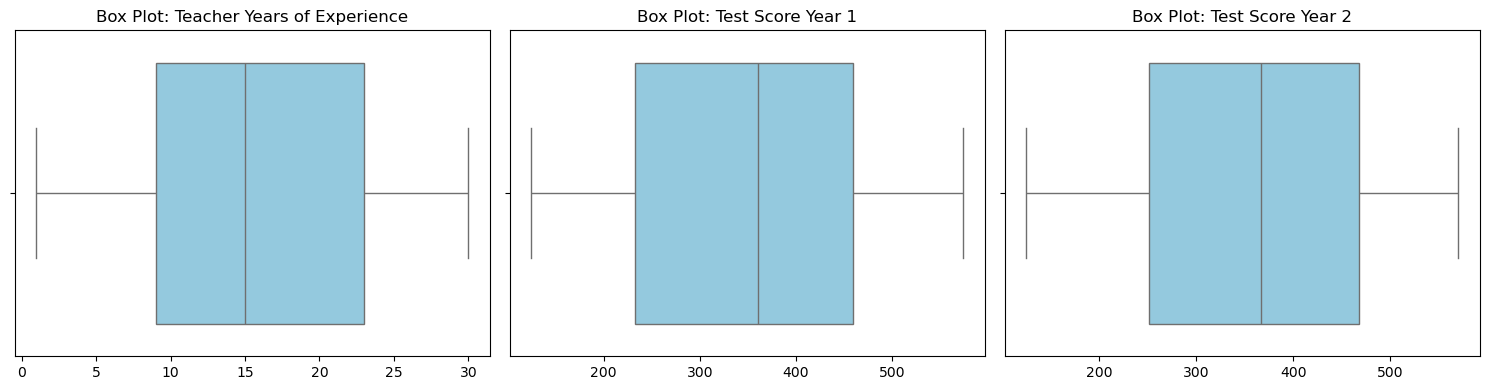

In [41]:
#whisker plot
cols_to_plot = [
    'Teacher Years of Experience',
    'Test Score Year 1',
    'Test Score Year 2'
]

#set up grid layout
num_vars = len(cols_to_plot)
cols_per_row = 3
rows = (num_vars + cols_per_row - 1) // cols_per_row

plt.figure(figsize=(15, 4 * rows))

for i, col in enumerate(cols_to_plot, 1):
  plt.subplot(rows, cols_per_row, i)
  sns.boxplot(x=clean_df[col], color='skyblue')
  plt.title(f'Box Plot: {col}', fontsize=12)
  plt.xlabel('')

plt.tight_layout()
plt.show()

<div style="display: inline-flex; align-items: center; background: #FDF2F2; color: #9B4D4D; border: 1px solid #F5C6C6; padding: 4px 10px; border-radius: 4px; font-weight: 500; font-size: 12px;">
 DataFrame: clean_df2
</div>

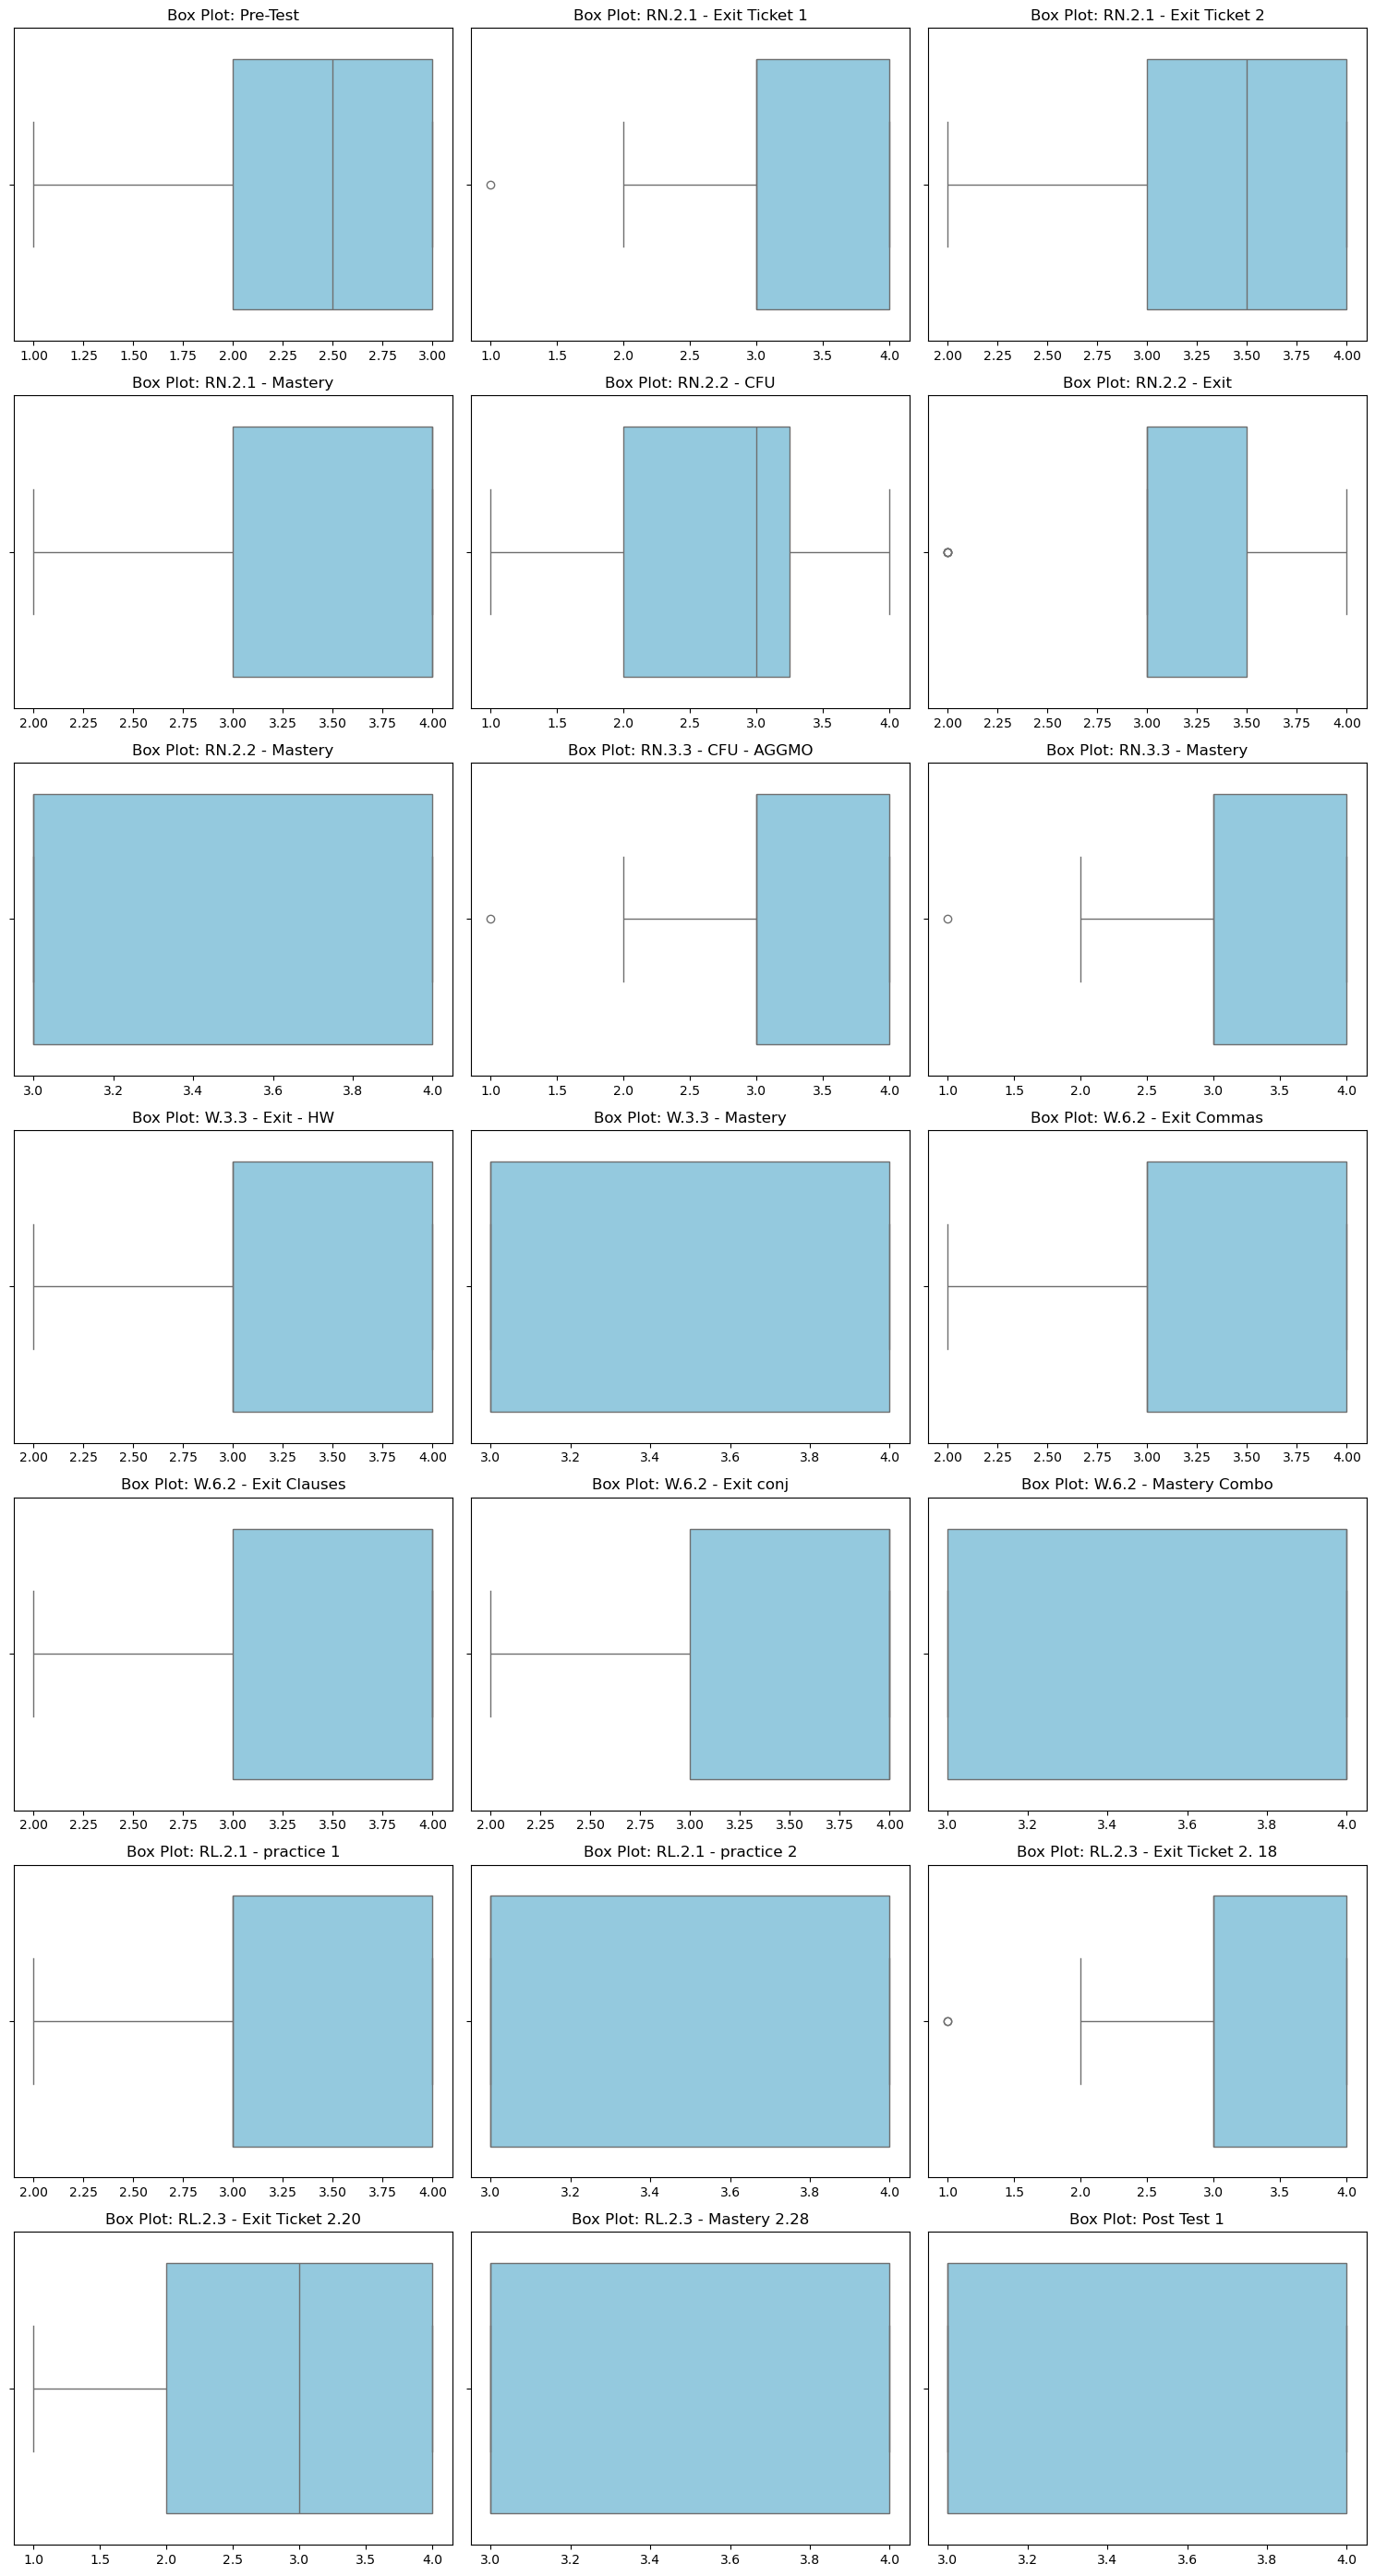

In [42]:
#whisker plot
cols_to_plot = [
    'Pre-Test', 'RN.2.1 - Exit Ticket 1', 'RN.2.1 - Exit Ticket 2', 'RN.2.1 - Mastery', 'RN.2.2 - CFU', 'RN.2.2 - Exit', 'RN.2.2 - Mastery', 'RN.3.3 - CFU - AGGMO', 'RN.3.3 - Mastery', 'W.3.3 - Exit - HW', 'W.3.3 - Mastery', 'W.6.2 - Exit Commas', 'W.6.2 - Exit Clauses', 'W.6.2 - Exit conj', 'W.6.2 - Mastery Combo', 'RL.2.1 - practice 1', 'RL.2.1 - practice 2', 'RL.2.3 - Exit Ticket 2. 18', 'RL.2.3 - Exit Ticket 2.20', 'RL.2.3 - Mastery 2.28', 'Post Test 1'
]

#set up grid layout
num_vars = len(cols_to_plot)
cols_per_row = 3
rows = (num_vars + cols_per_row - 1) // cols_per_row

plt.figure(figsize=(15, 4 * rows))

for i, col in enumerate(cols_to_plot, 1):
  plt.subplot(rows, cols_per_row, i)
  sns.boxplot(x=clean_df2[col], color='skyblue')
  plt.title(f'Box Plot: {col}', fontsize=12)
  plt.xlabel('')

plt.tight_layout()
plt.show()

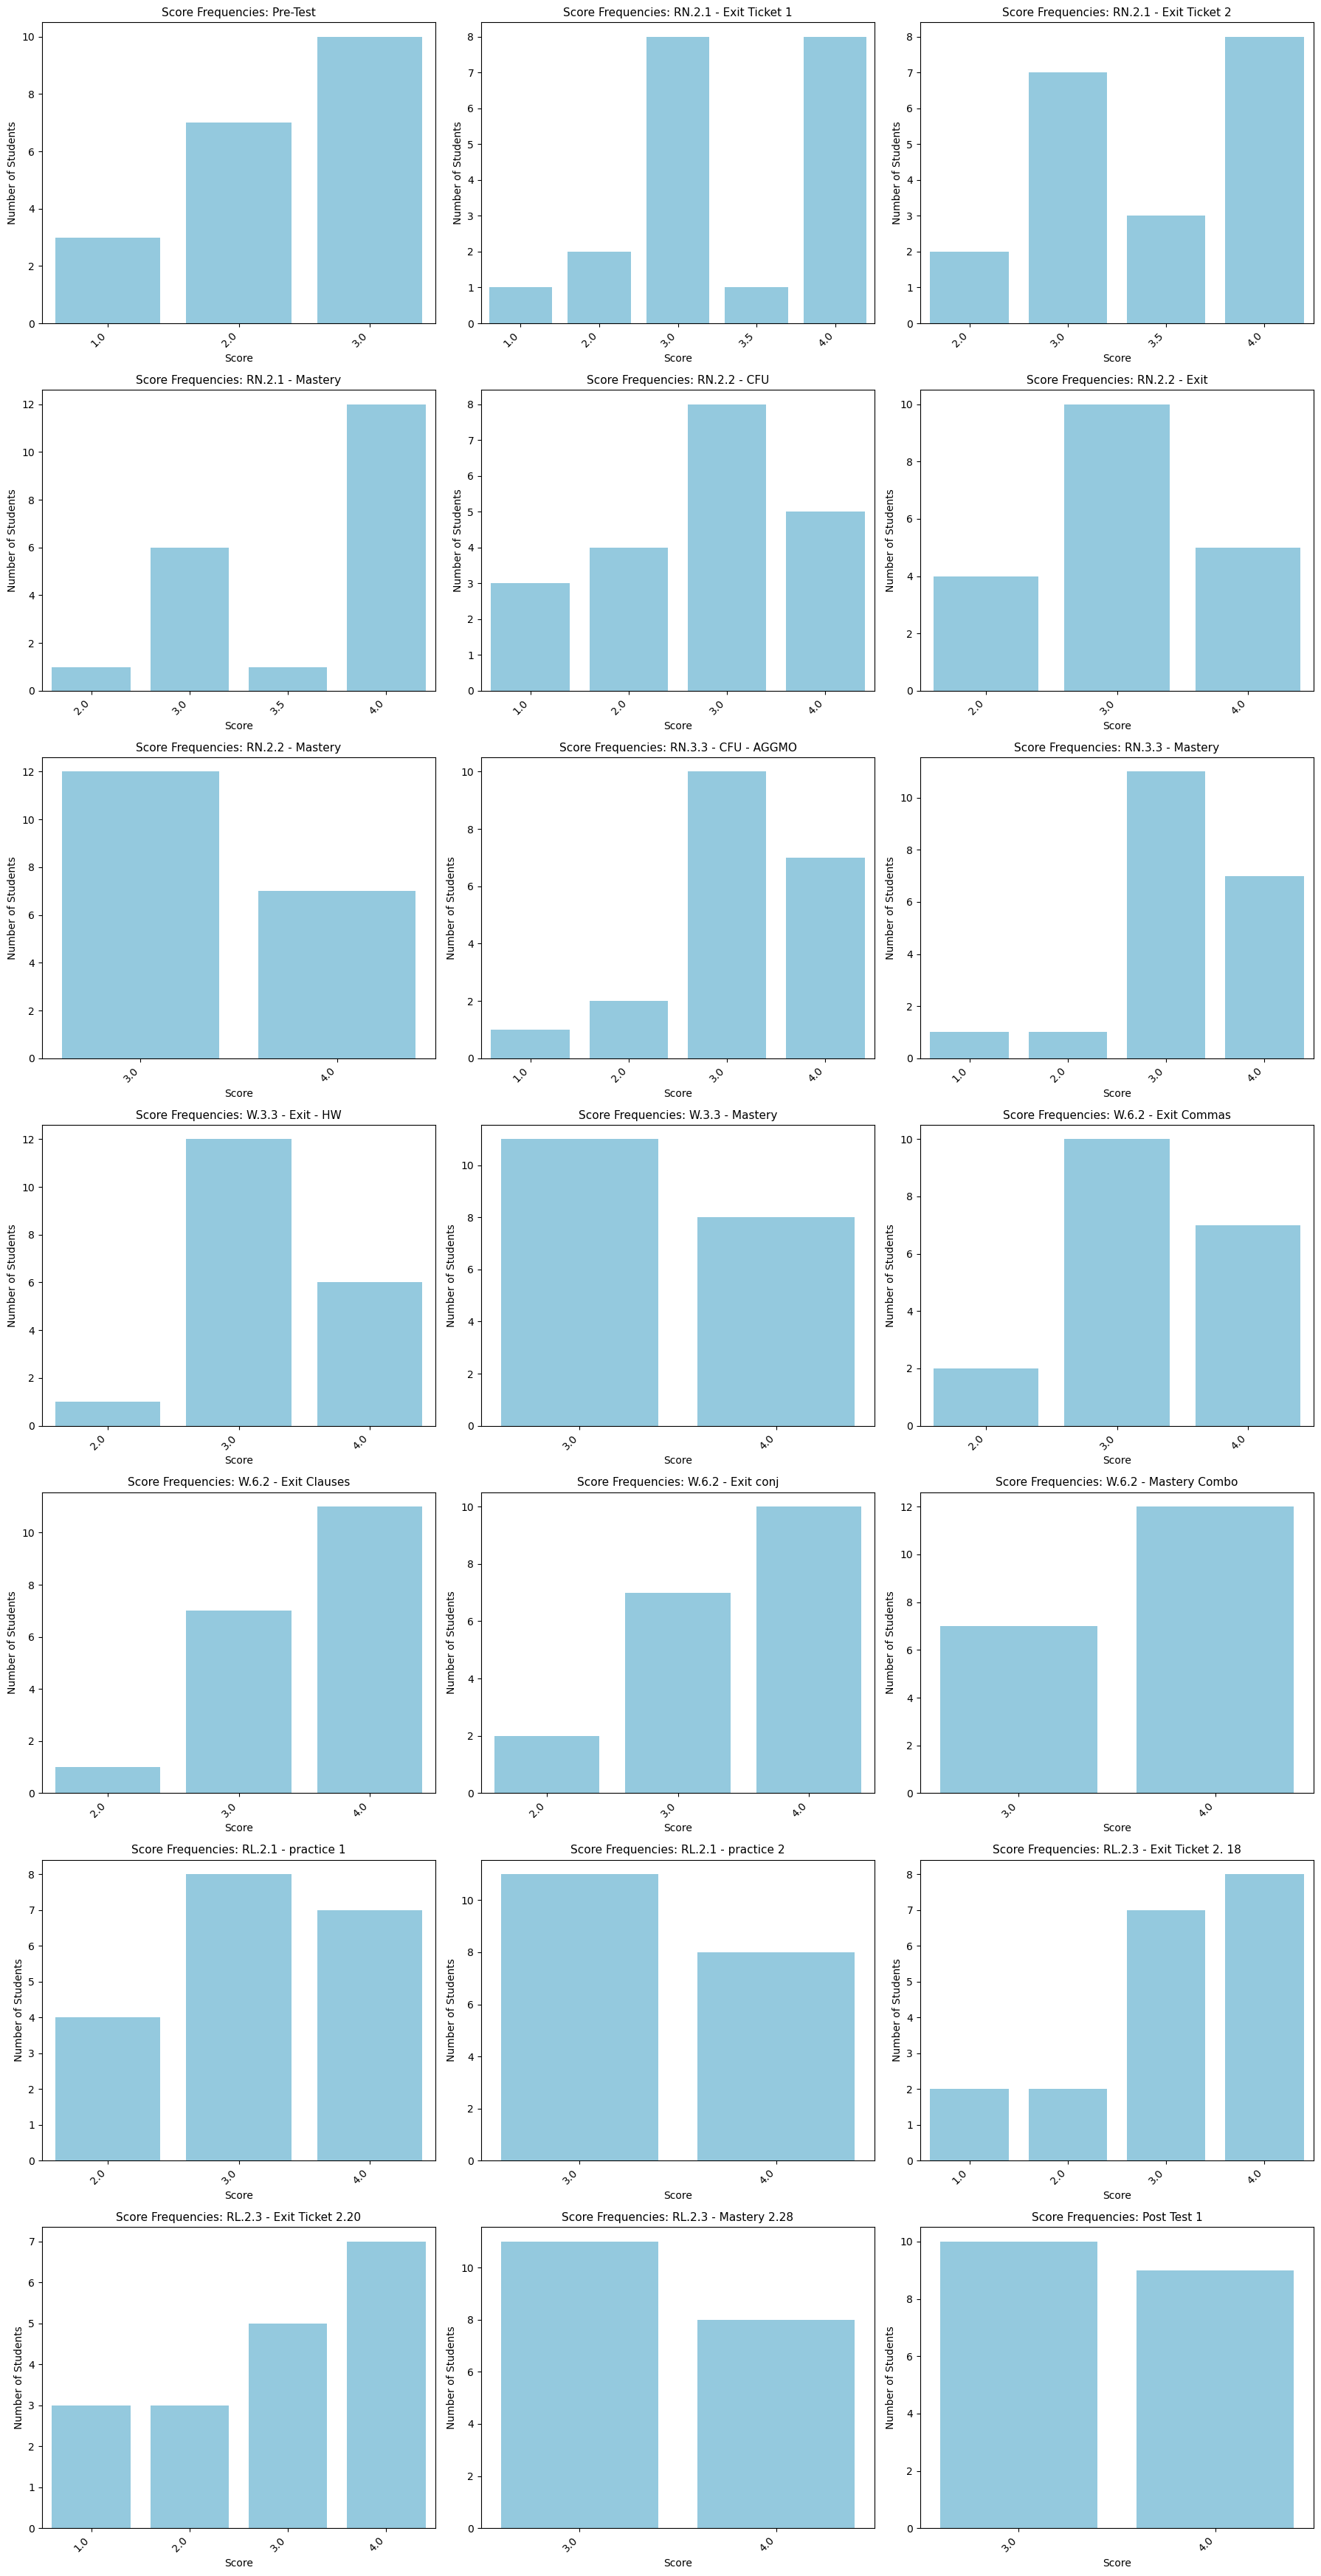

In [43]:
#bar chart for more visualization

cols_to_plot = [
    'Pre-Test', 'RN.2.1 - Exit Ticket 1', 'RN.2.1 - Exit Ticket 2', 'RN.2.1 - Mastery', 
    'RN.2.2 - CFU', 'RN.2.2 - Exit', 'RN.2.2 - Mastery', 'RN.3.3 - CFU - AGGMO', 
    'RN.3.3 - Mastery', 'W.3.3 - Exit - HW', 'W.3.3 - Mastery', 'W.6.2 - Exit Commas', 
    'W.6.2 - Exit Clauses', 'W.6.2 - Exit conj', 'W.6.2 - Mastery Combo', 
    'RL.2.1 - practice 1', 'RL.2.1 - practice 2', 'RL.2.3 - Exit Ticket 2. 18', 
    'RL.2.3 - Exit Ticket 2.20', 'RL.2.3 - Mastery 2.28', 'Post Test 1'
]

#grid layout
num_vars = len(cols_to_plot)
cols_per_row = 3
rows = (num_vars + cols_per_row - 1) // cols_per_row

plt.figure(figsize=(18, 5 * rows))

for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(rows, cols_per_row, i)
    
    sns.countplot(data=clean_df2, x=col, color='skyblue')
    
    plt.title(f'Score Frequencies: {col}', fontsize=11)
    plt.xlabel('Score', fontsize=10)
    plt.ylabel('Number of Students', fontsize=10)
    plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

<div style="display: inline-flex; align-items: center; background: #FDF2F2; color: #9B4D4D; border: 1px solid #F5C6C6; padding: 4px 10px; border-radius: 4px; font-weight: 500; font-size: 12px;">
 DataFrame: clean_df3
</div>

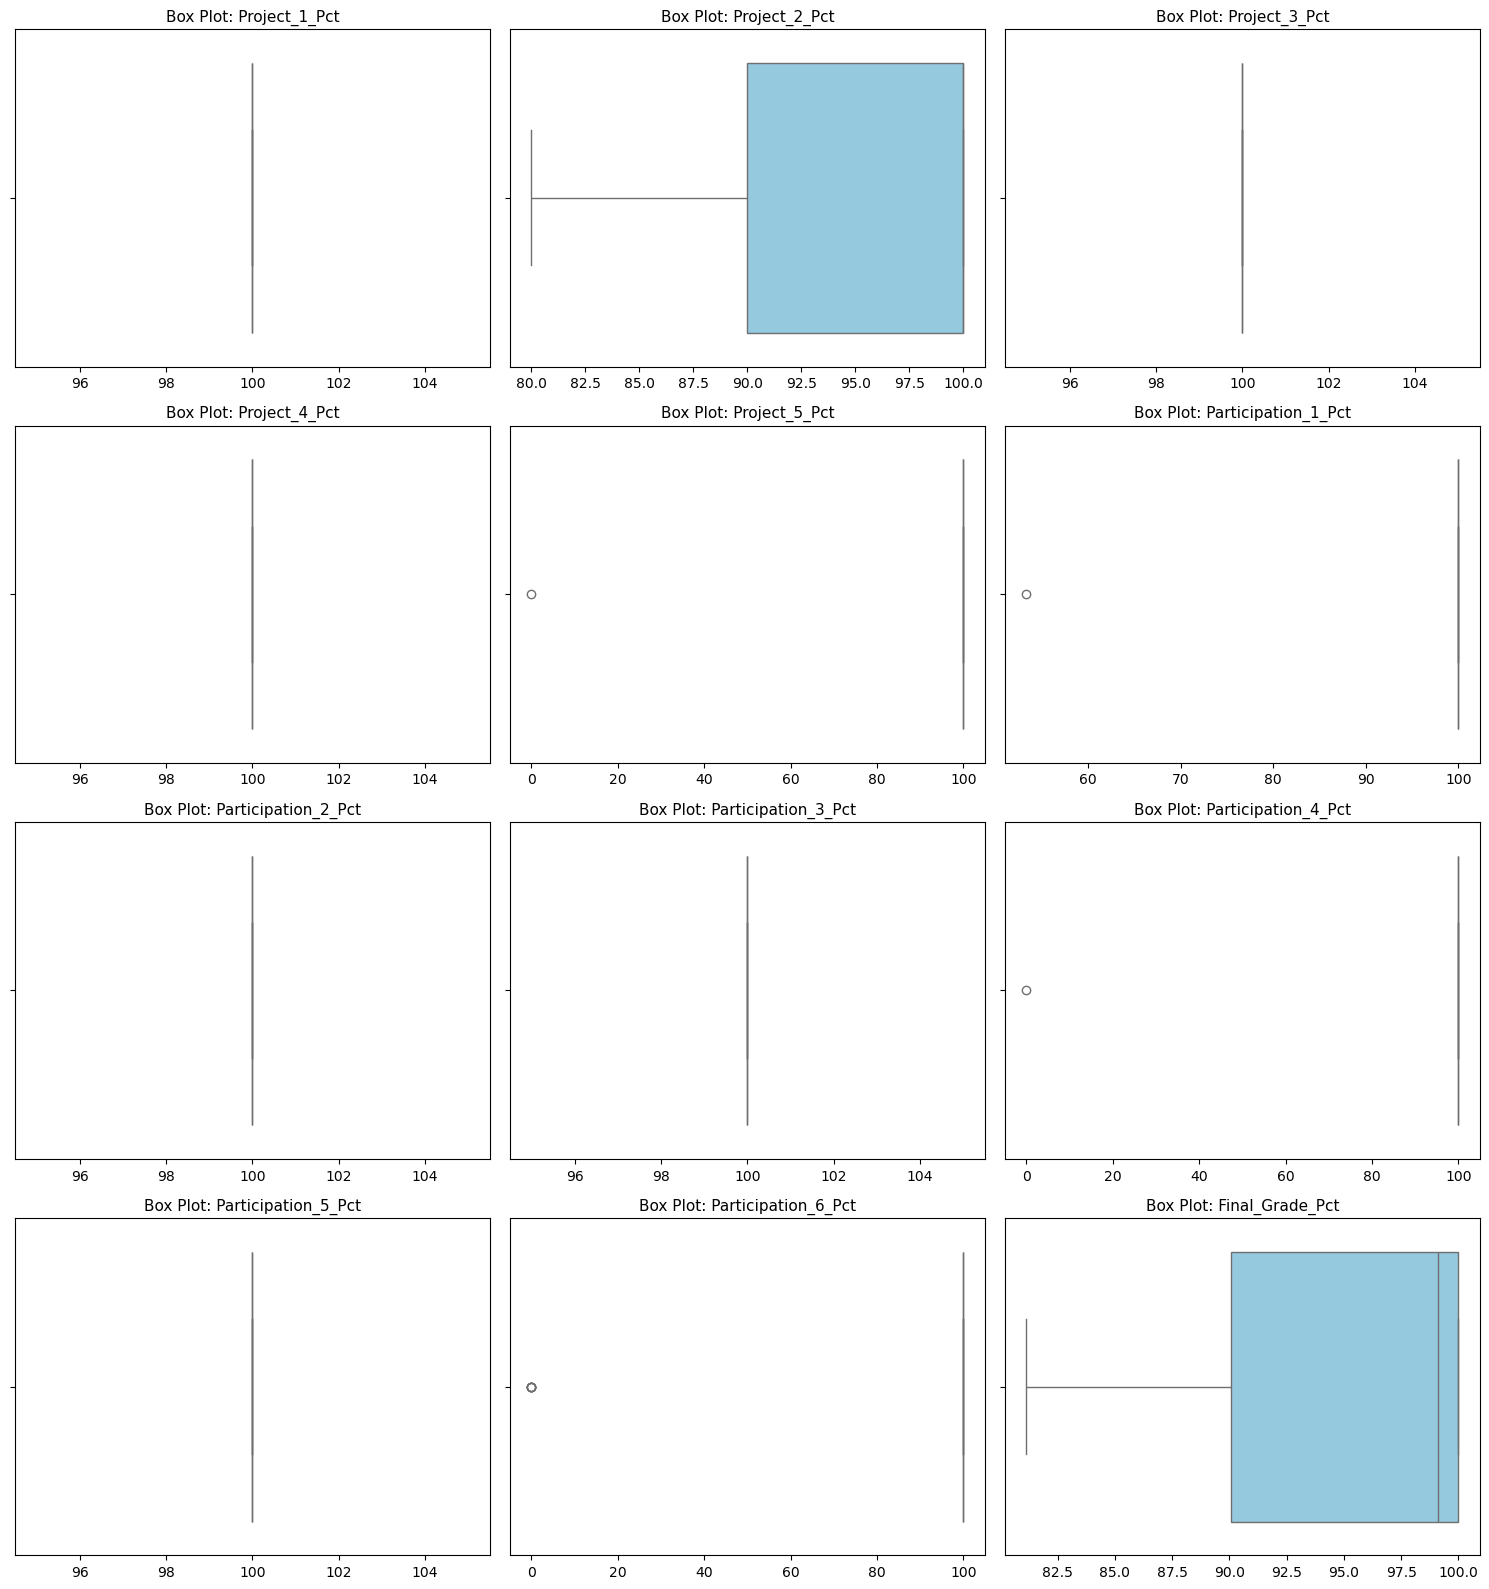

In [48]:
# Define the columns for clean_df3
cols_to_plot = [
'Project_1_Pct','Project_2_Pct','Project_3_Pct','Project_4_Pct','Project_5_Pct','Participation_1_Pct','Participation_2_Pct','Participation_3_Pct','Participation_4_Pct','Participation_5_Pct','Participation_6_Pct','Final_Grade_Pct'
]

# Set up grid layout (3 columns wide)
num_vars = len(cols_to_plot)
cols_per_row = 3
rows = (num_vars + cols_per_row - 1) // cols_per_row

plt.figure(figsize=(15, 4 * rows))

for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(rows, cols_per_row, i)
    sns.boxplot(x=clean_df3[col], color='skyblue')
    plt.title(f'Box Plot: {col}', fontsize=11)
    plt.xlabel('')

plt.tight_layout()
plt.show()

<div style="margin: 20px 0 12px 0; border-bottom: 2px solid #4C1D95; padding-bottom: 6px;">
    <span style="background: linear-gradient(135deg, #4C1D95 0%, #4C1D95 100%); color: white; padding: 4px 10px; border-radius: 4px; font-size: 11px; font-weight: 700; text-transform: uppercase; letter-spacing: 0.5px;">STEP 10</span>
    <span style="font-size: 16px; font-weight: 700; color: #1e293b; margin-left: 8px;">Create Pickle</span>
</div>
<p style="font-size: 13px; color: #475569; line-height: 1.6; margin: 10px 0;">

In [49]:
#pickle
all_dfs = {
    "df" : df,
    "clean_df": clean_df,
    "df2" : df2,
    "clean_df2": clean_df2,
    "df3" : df3,
    "clean_df3": clean_df3,
}
pd.to_pickle(all_dfs, 'all_clean_dfs3.pkl')